0) Importing libraries and setting up the environment

In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
np.random.seed(42)

from pandas.tseries.holiday import USFederalHolidayCalendar as Calendar
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.figsize"] = (12,4)

1) Loading CSV file

In [2]:
CSV_NAME = "PJME_hourly.csv"

 2. Loading the dataset and cleaning the columns

In [3]:
df = pd.read_csv(CSV_NAME)

In [4]:
df = df.rename(columns={"Datetime": "DATE_TIME", "PJME_MW": "USAGE"})

In [5]:
# Turning DATE_TIME into a datetime type so we can extract hour,day,holiday features
df["DATE_TIME"] = pd.to_datetime(df["DATE_TIME"], errors="coerce")
# Turning USAGE into numbers so math and ML models work and bad values become NaN
df["USAGE"] = pd.to_numeric(df["USAGE"], errors="coerce")

In [6]:
# Dropping bad rows and sorting by time
df = df.dropna(subset=["DATE_TIME", "USAGE"]).sort_values("DATE_TIME").reset_index(drop=True)

3. Visualizating the data

            DATE_TIME    USAGE
0 2002-01-01 01:00:00  30393.0
1 2002-01-01 02:00:00  29265.0
2 2002-01-01 03:00:00  28357.0
3 2002-01-01 04:00:00  27899.0
4 2002-01-01 05:00:00  28057.0
                           DATE_TIME          USAGE
count                         145366  145366.000000
mean   2010-04-18 03:25:25.999201536   32080.222831
min              2002-01-01 01:00:00   14544.000000
25%              2006-02-23 14:15:00   27573.000000
50%              2010-04-18 04:30:00   31421.000000
75%              2014-06-10 18:45:00   35650.000000
max              2018-08-03 00:00:00   62009.000000
std                              NaN    6464.012166


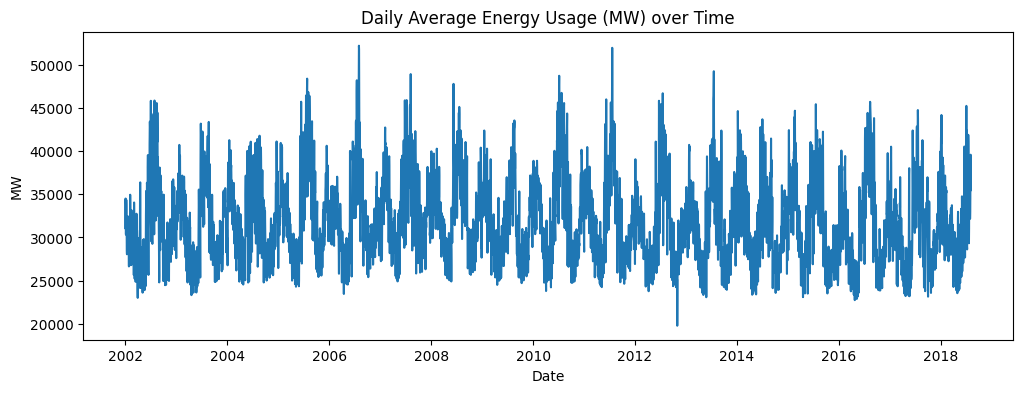

In [7]:
print(df.head())
print(df.describe())

# Plotting full series (downsampled daily mean so it’s readable)
daily = df.set_index("DATE_TIME")["USAGE"].resample("D").mean()
plt.figure()
plt.plot(daily)
plt.title("Daily Average Energy Usage (MW) over Time")
plt.xlabel("Date")
plt.ylabel("MW")
plt.show()


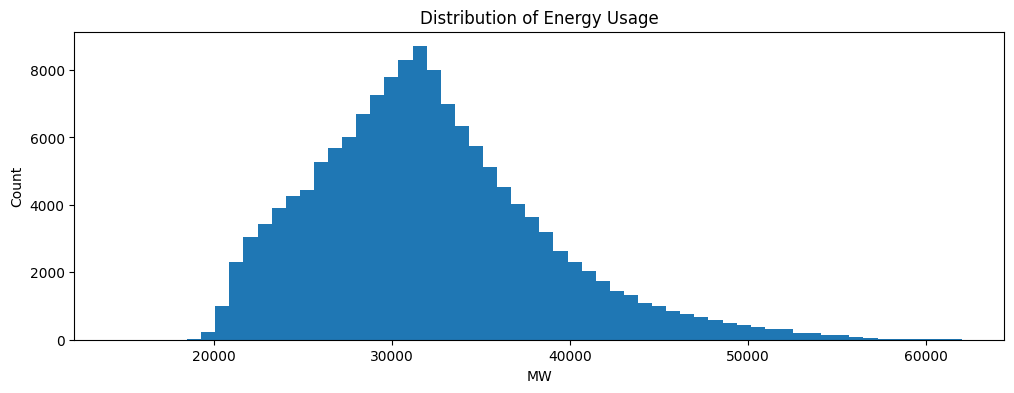

In [8]:
# Histogram to see distribution
plt.figure()
plt.hist(df["USAGE"], bins=60)
plt.title("Distribution of Energy Usage")
plt.xlabel("MW")
plt.ylabel("Count")
plt.show()

4. Feature engineering

In [9]:
# Creating a weekend type indicator so the model can learn different demand patterns on weekends
# Only Sunday is marked as 1 and all other days are 0
df["DAY_TYPE"] = df["DATE_TIME"].dt.dayofweek.apply(lambda x: 1 if x > 5 else 0)

In [10]:
# Identifying U.S. federal holidays and marking them because electricity usage often shifts on holidays
cal = Calendar()
holidays = cal.holidays(start=df["DATE_TIME"].min(), end=df["DATE_TIME"].max())
df["IS_HOLIDAY"] = df["DATE_TIME"].dt.normalize().isin(holidays).astype(int)


In [11]:
# Adding lagged usage values from the previous 5 hours so the model can use recent history to predict the next hour
for k in range(1, 6):
    df[f"t_{k}"] = df["USAGE"].shift(k)

In [12]:
# Filling the first few missing lag values with 0 to keep inputs numeric and consistent
df.fillna(0.0, inplace=True)

In [13]:
# Defining which columns will be used as inputs features and which one is the prediction target
feature_cols = ["DAY_TYPE", "IS_HOLIDAY", "t_1", "t_2", "t_3", "t_4", "t_5"]
target_col = "USAGE"

5. Visualizating

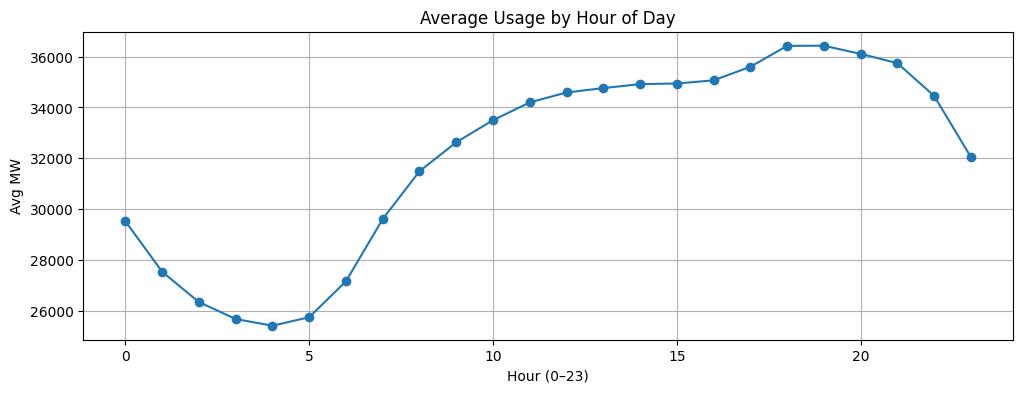

In [14]:
# Average usage by hour of day
hourly_avg = df.groupby(df["DATE_TIME"].dt.hour)["USAGE"].mean()
plt.figure()
plt.plot(hourly_avg.index, hourly_avg.values, marker="o")
plt.title("Average Usage by Hour of Day")
plt.xlabel("Hour (0–23)")
plt.ylabel("Avg MW")
plt.grid(True)
plt.show()

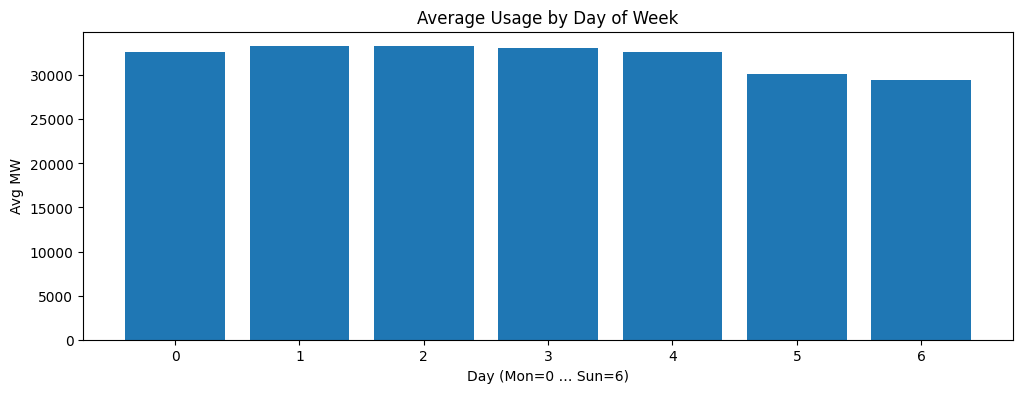

In [15]:
# Average usage by day of week
dow_avg = df.groupby(df["DATE_TIME"].dt.dayofweek)["USAGE"].mean()
plt.figure()
plt.bar(dow_avg.index, dow_avg.values)
plt.title("Average Usage by Day of Week")
plt.xlabel("Day (Mon=0 … Sun=6)")
plt.ylabel("Avg MW")
plt.show()

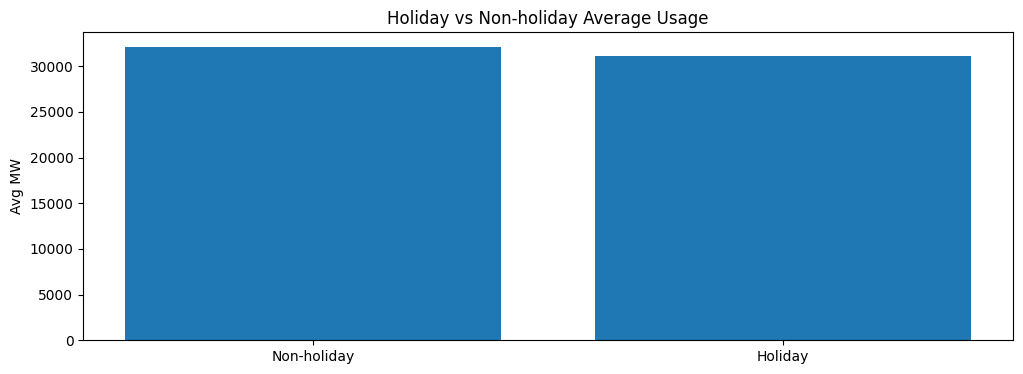

In [16]:
# Holidays vs non holidays
holiday_avg = df.groupby("IS_HOLIDAY")["USAGE"].mean()
plt.figure()
plt.bar(["Non-holiday", "Holiday"], holiday_avg.values)
plt.title("Holiday vs Non-holiday Average Usage")
plt.ylabel("Avg MW")
plt.show()

6. Time based splits

In [17]:
# Setting cut off dates for a time based split so the model trains on past data
# and is validated and tested on future data to avoid leaking future information
TRAIN_END = pd.to_datetime("2017-01-01")   # training data ends before this date
VAL_END   = pd.to_datetime("2017-07-01")   # validation data ends before this date
TEST_BEG  = pd.to_datetime("2017-07-01")   # test data starts from here onward

In [18]:
# Creating boolean masks that label each row as train, validation or test based on time
mask_train = df["DATE_TIME"] < TRAIN_END
mask_val   = (df["DATE_TIME"] >= TRAIN_END) & (df["DATE_TIME"] < VAL_END)
mask_test  = df["DATE_TIME"] >= TEST_BEG

In [19]:
# Extracting the full feature matrix (X) and target vector (y) from the dataframe
X_full = df[feature_cols].values
y_full = df[target_col].values

In [20]:
# Appling the masks to split X and y into train,val and test sets in chronological order
X_train, y_train = X_full[mask_train], y_full[mask_train]
X_val,   y_val   = X_full[mask_val],   y_full[mask_val]
X_test,  y_test  = X_full[mask_test],  y_full[mask_test]

7. Visualizating

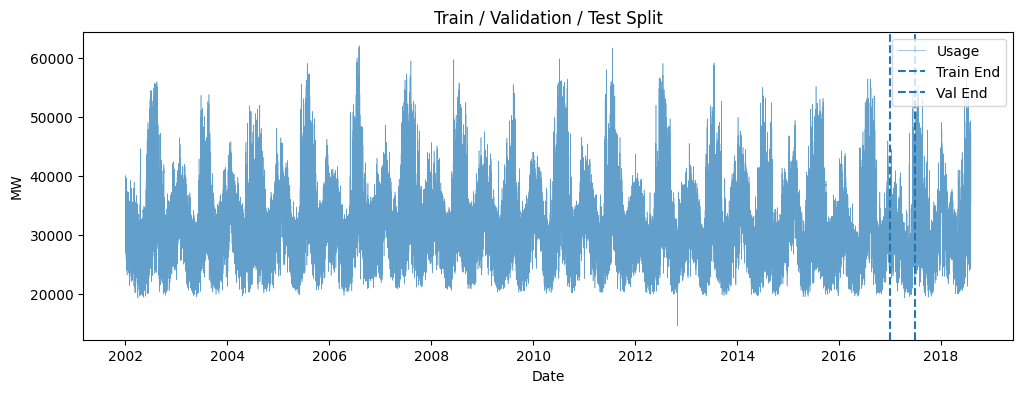

Train range: 2002-01-01 01:00:00 → 2016-12-31 23:00:00
Val range  : 2017-01-01 00:00:00 → 2017-06-30 23:00:00
Test range : 2017-07-01 00:00:00 → 2018-08-03 00:00:00


In [21]:
plt.figure()
plt.plot(df["DATE_TIME"], df["USAGE"], linewidth=0.4, alpha=0.7)
plt.axvline(TRAIN_END, linestyle="--")
plt.axvline(VAL_END, linestyle="--")
plt.title("Train / Validation / Test Split")
plt.xlabel("Date")
plt.ylabel("MW")
plt.legend(["Usage", "Train End", "Val End"])
plt.show()
print("Train range:", df.loc[mask_train, "DATE_TIME"].min(), "→", df.loc[mask_train, "DATE_TIME"].max())
print("Val range  :", df.loc[mask_val, "DATE_TIME"].min(), "→", df.loc[mask_val, "DATE_TIME"].max())
print("Test range :", df.loc[mask_test, "DATE_TIME"].min(), "→", df.loc[mask_test, "DATE_TIME"].max())

8. Feature scaling

In [22]:
scaler = StandardScaler()              # creates a scaler to make features mean=0 and std=1
X_train_s = scaler.fit_transform(X_train)  # learning scaling from train set and applying it
X_val_s   = scaler.transform(X_val)        # Applying the same train scaling to validation
X_test_s  = scaler.transform(X_test)       # Applying the same train scaling to test

print(f"Shapes → train:{X_train_s.shape}, val:{X_val_s.shape}, test:{X_test_s.shape}")
# printing shapes to confirm splits and scaling worked correctly

Shapes → train:(131470, 7), val:(4343, 7), test:(9553, 7)


9. Visualizating

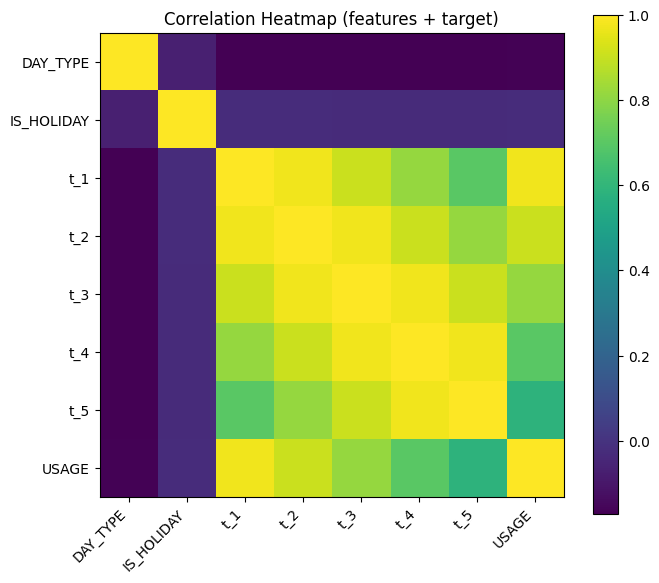

In [23]:
corr = df[feature_cols + [target_col]].corr().values

plt.figure(figsize=(7,6))
plt.imshow(corr)
plt.title("Correlation Heatmap (features + target)")
plt.xticks(range(len(feature_cols + [target_col])), feature_cols + [target_col], rotation=45, ha="right")
plt.yticks(range(len(feature_cols + [target_col])), feature_cols + [target_col])
plt.colorbar()
plt.tight_layout()
plt.show()